<hr>

<font color=skyblue>**去除模糊影像的 CNN 深度學習實驗（Image Deblurring using Convolutional Neural Networks and Deep Learning）**</font>

<font color=skyblue>**Part 3: Training the models and evaluating their performance**</font>

Reference: 

教學網站：https://debuggercafe.com/image-deblurring-using-convolutional-neural-networks-and-deep-learning/

參考論文(2018)：https://www.researchgate.net/publication/328985265_Image_Deblurring_and_Super-Resolution_Using_Deep_Convolutional_Neural_Networks#fullTextFileContent
<hr>

<font color=yellow>Import packages</font>
<hr>

In [3]:
import cv2
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision.transforms import transforms
# below is for the custom defs
from Deblurring_defs import  (
    DeblurDataset, DeblurCNN, DeblurCNN_RES, DeblurSuperResCNN, psnr
)

<font color=yellow>Set up global constants and variables</font>


In [32]:
DIR_PATH = 'Deblur/' # Directory path for the inputs and outputs
# IMG_RESIZE = (33, 33) # 注意：依據訓練資料大小不同，將訓練影像大小改為 33x33
# BATCH_SIZE = 128 # 根據訓練資料大小和GPU記憶體容量，調整批次大小
IMG_RESIZE = (224, 224) # 注意：將訓練影像大小改為 224x224
BATCH_SIZE = 2
LEARNING_RATE = 0.001 # Learning rate.
NUM_EPOCHS = 20 # Number of epochs to train the model
WEIGHTS = DIR_PATH + 'outputs/pre_trained_model.pt' # the pre-trained model

blur_path = DIR_PATH + 'inputs/General100_gaussian_blurred_sigmax3' # Directory containing the blurred images
sharp_path = DIR_PATH + 'inputs/General100' # Directory containing the sharp images


<hr>
<font color=yellow>Setup the CNN model</font>: Three Models<br><br>


<img src="..\Copilot_20260514_224706.png" style="width:600px; height:auto;">
<img src="..\Copilot_20260514_225009.png" style="width:600px; height:auto;">
<img src="..\Copilot_20260511_162827.png" style="width:600px; height:auto;">
<hr>

In [26]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
print('Using {} device'.format(device))

model = DeblurCNN().to(device)
# model = DeblurCNN_RES().to(device)
# model = DeblurSuperResCNN().to(device)

print(f"Model: {model}")

total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params:,} total parameters.")

total_trainable_params = sum(
        p.numel() for p in model.parameters() if p.requires_grad)
print(f"{total_trainable_params:,} training parameters.")

lr = LEARNING_RATE # Learning rate.
optimizer = optim.Adam(model.parameters(), lr=lr)
print(f"Learning rate: {lr}")
print(f"Optimizer: {optimizer}")
# Loss function.
criterion = nn.MSELoss()
print(f"Loss function: {criterion}")

# scheduler is to reduce the learning rate when a monitored 
# metric (like validation loss) stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( 
        optimizer,
        mode='min',
        patience=5,
        factor=0.5,
        # verbose=True
    )

Using cuda device
Model: DeblurCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)
20,099 total parameters.
20,099 training parameters.
Learning rate: 0.001
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Loss function: MSELoss()


<hr>
<font color=yellow>Reloading the pre-trained model if any</font>

從頭訓練模型需要很長的時間，尤其是當訓練資料集很大時。因此，我們可以先訓練一個模型，然後將其權重保存下來，以便在未來的訓練中重新加載。這樣可以節省時間，並且可以在不同的訓練過程中使用相同的模型權重。
<hr>

In [36]:
# resume training if weights are present.
if os.path.exists(WEIGHTS):
    print('Weights file found. Resuming training...')

    checkpoint = torch.load(WEIGHTS, map_location=device)
    saved_model_class = checkpoint.get('model_class', 'Unknown')
    saved_model_init_args = checkpoint.get('model_init_args', {})
    print(f"Saved model class: {saved_model_class}")
    print(f"Saved model init args: {saved_model_init_args}")
    
    print("Resuming the model state...")
    model.load_state_dict(checkpoint['model_state_dict'])
    pre_trained_epoch = checkpoint['epoch']
    print(f"Resuming training from epoch: {pre_trained_epoch}")
    # Load the optimizer state if available. may not be good idea to resume.
    print("Resuming the optimizer state...")
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
else:
    checkpoint = None
    pre_trained_epoch = 0
    print('No pre-trained file found. Starting training from scratch...')
print(f"Current Model: {model}")


Weights file found. Resuming training...
Saved model class: DeblurCNN
Saved model init args: {}
Resuming the model state...
Resuming training from epoch: 20
Resuming the optimizer state...
Current Model: DeblurCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)


<hr>
<font color=yellow>Prepare training and validating data</font>
<hr>

In [28]:
gauss_blur = os.listdir(blur_path)
gauss_blur.sort()
sharp = os.listdir(sharp_path)
sharp.sort()
x_blur = [] # images names for gauss blurred images
for i in range(len(gauss_blur)):
    x_blur.append(gauss_blur[i])
y_sharp = [] # images names for sharp images
for i in range(len(sharp)):
    y_sharp.append(sharp[i])

(x_train, x_val, y_train, y_val) = train_test_split(x_blur, y_sharp, test_size=0.1)
print(f"Train data instances: {len(x_train)}")
print(f"Validation data instances: {len(x_val)}")

# define transforms to resize and convert images to tensor
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(IMG_RESIZE),
    transforms.ToTensor(),
])
# use the custom dataset class to create datasets for training and validation
train_data = DeblurDataset(blur_path, x_train, sharp_path, y_train, transform)
val_data = DeblurDataset(blur_path, x_val, sharp_path, y_val, transform)
 
trainloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
valloader = DataLoader(val_data, batch_size=1, shuffle=False)

Train data instances: 90
Validation data instances: 10


<hr>
<font color=yellow>Define training process</font>
<hr>

In [29]:
def fit(model, dataloader, epoch):
    model.train()
    running_loss = 0.0
    running_psnr = 0.0
    for i, data in tqdm(enumerate(dataloader), total=len(dataloader)):
        blur_image = data[0]
        sharp_image = data[1]
        blur_image = blur_image.to(device)
        sharp_image = sharp_image.to(device)
        optimizer.zero_grad()
        outputs = model(blur_image)
        loss = criterion(outputs, sharp_image)
        # backpropagation
        loss.backward()
        # update the parameters
        optimizer.step()
        running_loss += loss.item()
        running_psnr +=  psnr(sharp_image, outputs)
    
    train_loss = running_loss/len(dataloader.dataset)
    train_psnr = running_psnr/len(dataloader)
    print(f"Train Loss: {train_loss:.5f} - Train PSNR: {train_psnr:.2f} dB")
    # print(f"Train Loss: {train_loss:.5f}")
    
    return train_loss, train_psnr

<hr>
<font color=yellow>Define validating process</font>
<hr>

In [30]:
def validate(model, dataloader, epoch):
    model.eval()
    running_loss = 0.0
    running_psnr = 0.0
    with torch.no_grad():
        for i, data in tqdm(enumerate(dataloader), total=len(dataloader)):
            blur_image = data[0]
            sharp_image = data[1]
            blur_image = blur_image.to(device)
            sharp_image = sharp_image.to(device)
            outputs = model(blur_image)
            loss = criterion(outputs, sharp_image)
            running_loss += loss.item()
            running_psnr +=  psnr(sharp_image, outputs)
            
            
        val_loss = running_loss/len(dataloader.dataset)
        val_psnr = running_psnr/len(dataloader)
        print(f"Val Loss: {val_loss:.5f} - Val PSNR: {val_psnr:.2f} dB")
        
        return val_loss, val_psnr

<hr>
<font color=yellow>Start training and save results for further analysis, visualization and training continuation</font>
<hr>

In [ ]:
train_loss, val_loss = [], []
train_psnr, val_psnr = [], []
start_time = time.time()
epochs = NUM_EPOCHS
for epoch in range(epochs):
    print(f"Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_psnr = fit(model, trainloader, epoch)
    val_epoch_loss, val_epoch_psnr = validate(model, valloader, epoch)
    train_loss.append(train_epoch_loss)
    train_psnr.append(train_epoch_psnr)
    val_loss.append(val_epoch_loss)
    val_psnr.append(val_epoch_psnr)
    scheduler.step(val_epoch_loss)

end_time = time.time()
print(f"Took {((end_time-start_time)/60):.3f} minutes to train")
print('Saving model...')

# Load previous checkpoint safely (if any).
loaded_checkpoint = torch.load(WEIGHTS) if os.path.exists(WEIGHTS) else None

pre_trained_epoch = loaded_checkpoint['epoch'] if loaded_checkpoint is not None else 0
cumulative_epochs = epochs + pre_trained_epoch

# cumulative training loss from the pre-trained model and the current training process
pre_trained_train_loss = loaded_checkpoint['train_loss'] if loaded_checkpoint is not None else []
pre_trained_val_loss = loaded_checkpoint['val_loss'] if loaded_checkpoint is not None else []
cumulative_train_loss = pre_trained_train_loss + train_loss
cumulative_val_loss = pre_trained_val_loss + val_loss

# cumulative PSNR from the pre-trained model and the current training process
pre_trained_train_psnr = loaded_checkpoint['train_psnr'] if loaded_checkpoint is not None else []
pre_trained_val_psnr = loaded_checkpoint['val_psnr'] if loaded_checkpoint is not None else []
cumulative_train_psnr = pre_trained_train_psnr + train_psnr
cumulative_val_psnr = pre_trained_val_psnr + val_psnr

# Save weights + model structure metadata for easier restore/rebuild.
torch.save({
    'epoch': cumulative_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'model_class': model.__class__.__name__,
    'model_init_args': {},
    'model_str': str(model),
    'train_loss': cumulative_train_loss,
    'val_loss': cumulative_val_loss,
    'train_psnr': cumulative_train_psnr,
    'val_psnr': cumulative_val_psnr
}, WEIGHTS)
print(f"Model saved as {WEIGHTS}")

<font color=yellow>Display the Loss and PSNR values over the epochs</font>

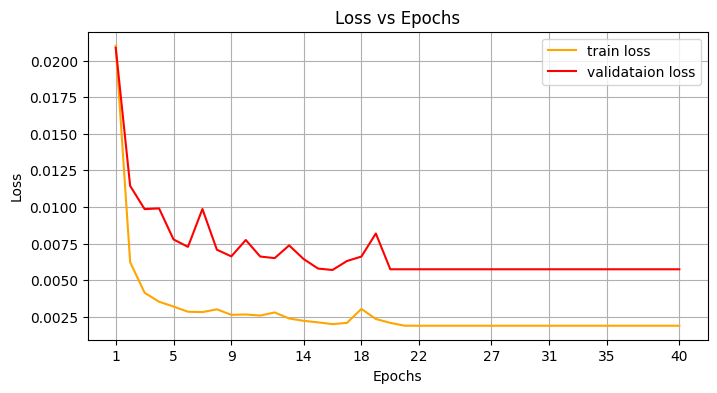

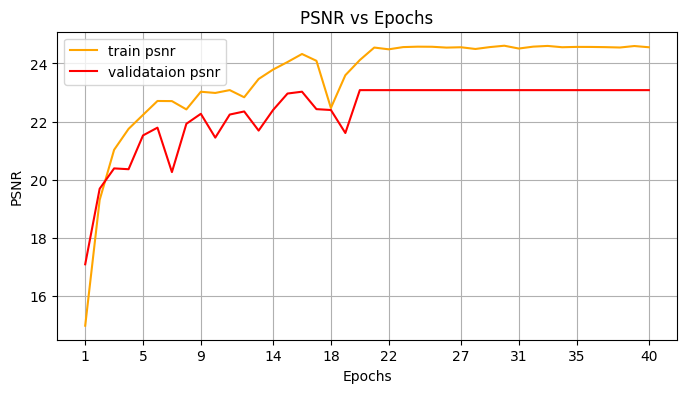

In [38]:
# loss plots
import matplotlib.pyplot as plt
import numpy as np

# load the pre-trained loss values if available
checkpoint = torch.load(WEIGHTS) if os.path.exists(WEIGHTS) else None
pre_trained_train_loss = checkpoint['train_loss'] if os.path.exists(WEIGHTS) else 0.0
pre_trained_val_loss = checkpoint['val_loss'] if os.path.exists(WEIGHTS) else 0.0

# load the pre-trained PSNR values if available
pre_trained_train_psnr = checkpoint['train_psnr'] if os.path.exists(WEIGHTS) else 0.0
pre_trained_val_psnr = checkpoint['val_psnr'] if os.path.exists(WEIGHTS) else 0.0

plt.figure(figsize=(8, 4))
plt.plot(pre_trained_train_loss, color='orange', label='train loss')
plt.plot(pre_trained_val_loss, color='red', label='validataion loss')

num_points = len(pre_trained_train_loss)
# num_ticks = 10 if num_points >= 10 else num_points
# if num_points >= 30, we can set num_ticks to 10 to avoid overcrowding the x-axis
if num_points >= 30:
    num_ticks = 10
else:
    num_ticks = num_points

tick_positions = np.linspace(0, num_points-1, num_ticks, dtype=int)
tick_labels = [ i + 1 for i in tick_positions]
plt.xticks(ticks=tick_positions, labels=tick_labels)

plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.savefig(DIR_PATH + 'outputs/loss.png')
plt.show()
# save the model to disk
plt.figure(figsize=(8, 4))
plt.plot(pre_trained_train_psnr, color='orange', label='train psnr')
plt.plot(pre_trained_val_psnr, color='red', label='validataion psnr')
plt.xticks(ticks=tick_positions, labels=tick_labels)
plt.title('PSNR vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('PSNR')
plt.legend()
plt.grid()
plt.savefig(DIR_PATH + 'outputs/psnr.png')
plt.show()


<font color=yellow>使用 pre-trained 模型進行去模糊處理</font>

- 輸入任意圖像
- 先進行高斯模糊化
- 轉換模糊圖像矩陣為 tensor 矩陣
- 再送入已預訓練好之 CNN 模型得到去除模糊圖像
- 轉換去除模糊圖像為 numpy 矩陣
- 最後呈現模型的表現。
- 以肉眼觀察去模糊圖像的品質，並與原始圖像和模糊圖像進行比較。還能再訓練嗎？

Loading the pre-trained model state...
Total epochs trained: 40
Saved model class: DeblurCNN
Saved model init args: {}


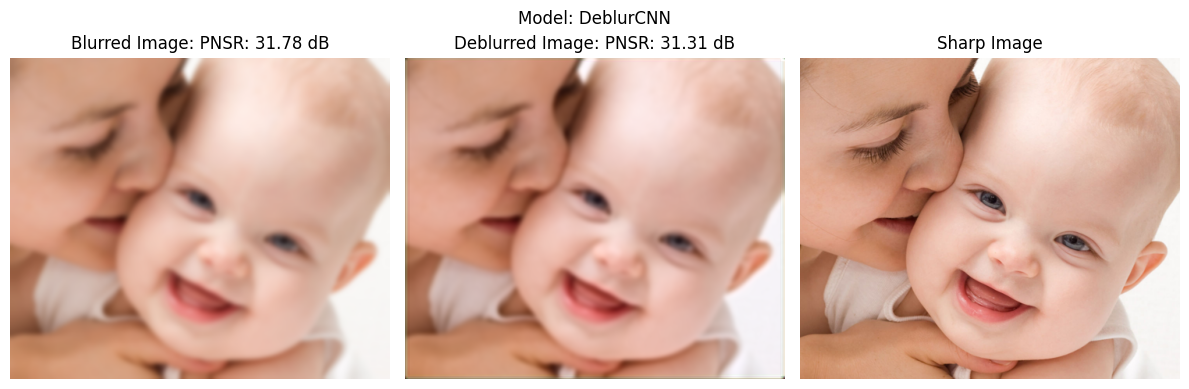

In [41]:
# select/load the pre-trained model
pre_trained_model = "pre_trained_model.pt"

# load the pre-trained model weights
WEIGHTS = DIR_PATH + 'outputs/' + pre_trained_model # Path to the pre-trained model
checkpoint = torch.load(WEIGHTS, map_location=device) if os.path.exists(WEIGHTS) else None
if checkpoint is not None:
    print("Loading the pre-trained model state...")
    print("Total epochs trained: {}".format(checkpoint['epoch']))

    saved_model_class = checkpoint.get('model_class', 'DeblurCNN') # default to 'DeblurCNN' if not found
    saved_model_init_args = checkpoint.get('model_init_args', {}) # default to empty dict if not found
    print(f"Saved model class: {saved_model_class}")
    print(f"Saved model init args: {saved_model_init_args}")

    if saved_model_class == 'DeblurCNN':
        model = DeblurCNN(**saved_model_init_args).to(device)
    elif saved_model_class == 'DeblurCNN_RES':
        model = DeblurCNN_RES(**saved_model_init_args).to(device)
    elif saved_model_class == 'DeblurSuperResCNN':
        model = DeblurSuperResCNN(**saved_model_init_args).to(device)
    else:
        print(f"Unknown saved model class '{saved_model_class}', fallback to DeblurCNN().")
        model = DeblurCNN().to(device)

    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
else:
    print("No pre-trained model found. Please train the model first.")
    model = DeblurCNN().to(device)

# load an image from pictures directory
sharp = cv2.imread(DIR_PATH + 'inputs/General100/im_015.PNG', cv2.IMREAD_COLOR)
sharp = cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB)
sharp_tensor = transforms.ToPILImage()(sharp)
sharp_tensor = transforms.ToTensor()(sharp_tensor)
sharp_tensor = sharp_tensor.unsqueeze(0) # add batch dimension
# add gaussian blurring
# blur = cv2.GaussianBlur(sharp, (15, 15), 0)
blur = cv2.GaussianBlur(sharp,(0, 0), sigmaX=3)
# convert the blur to tensor without resizing
blur_tensor = transforms.ToPILImage()(blur)
blur_tensor = transforms.ToTensor()(blur_tensor)
blur_tensor = blur_tensor.unsqueeze(0) # add batch dimension
blur_tensor = blur_tensor.to(device)

# deblur the image

with torch.no_grad():
    deblurred_tensor = model(blur_tensor)

psnr_blur = psnr(sharp_tensor, blur_tensor)
psnr_deblur = psnr(sharp_tensor, deblurred_tensor)

# plot the sharp, blurred and deblurred images side by side with PSNR values in the title
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
img0 = blur_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
img1 = deblurred_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
img2 = sharp_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()

# Clip to [0, 1] if float, or [0, 255] if uint8
img0 = np.clip(img0, 0, 1)
img1 = np.clip(img1, 0, 1)
img2 = np.clip(img2, 0, 1)

ax[0].imshow(img0)
ax[0].set_title('Blurred Image: PNSR: {:.2f} dB'.format(psnr_blur))
ax[0].axis('off')
ax[1].imshow(img1)
ax[1].set_title('Deblurred Image: PNSR: {:.2f} dB'.format(psnr_deblur))
ax[1].axis('off')
ax[2].imshow(img2)
ax[2].set_title('Sharp Image')
ax[2].axis('off')

plt.suptitle('Model: {}'.format(saved_model_class))
plt.tight_layout()
plt.show()


<hr>
<font color=skyblue>Download the dataset from Kaggle: 1.47G</font>

- sharp images : 350 images
- motion blurring images : 350 images
- defocus blurring images : 350 images


In [21]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("kwentar/blur-dataset")

# print("Path to dataset files:", path)